In [1]:
%run preds_dict.ipynb

Acc: 0.9805194805194806


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [3]:
final_clean_strained = load_data(db_level=0)

In [4]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)
final_clean_strained["Noise"] = final_clean_strained["Subject"].replace(preds_dict)

In [5]:
final_clean_strained = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Distance": "first",
            "Total Variance": "first",
        }
    )
    .reset_index()
)

In [6]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [8]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Noise", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Vanilla Linear Regression

In [9]:
final_clean_strained_70.columns

Index(['Subject', 'Frequency(kHz)', 'Level(dB)', 'Amplitude', 'SynapsesPerIHC',
       'IHCs', 'OrphansPerIHC', 'Waveform', 'WaveI', 'Peaks', 'Troughs',
       'Strain', 'Sex', 'Group', 'Noise', 'Time (str)', 'Time (hrs)',
       'Strain (binary)', 'PeakI Left Curvature', 'PeakI Overall Curvature',
       'PeakI Right Curvature', 'TroughI Left Curvature',
       'TroughI Overall Curvature', 'TroughI Right Curvature', 'Slope',
       'Distance', 'Total Variance', 'DataGroup'],
      dtype='object')

In [10]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "Slope",
    "Distance",
    "TotalVariance",
    "DataGroup",
]

In [11]:
import statsmodels.formula.api as smf


def VIF(reg: str):
    vif_model = smf.ols(reg, data=smf_df).fit()
    r2j = vif_model.rsquared
    vif_j = 1 / (1 - r2j)
    return vif_j


features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.18316
VIF for Amplitude: 23.14660
VIF for Slope: 11.16427
VIF for TotalVariance: 10.77397
VIF for Distance: 1.13991
VIF for Noise: 1.26005
VIF for Time_hrs: 1.19627
VIF for PeakILeftCurvature: 1.49340
VIF for PeakIOverallCurvature: 1.07986
VIF for PeakIRightCurvature: 1.71158
VIF for TroughILeftCurvature: 1.41338
VIF for TroughIOverallCurvature: 1.09384
VIF for TroughIRightCurvature: 1.11486


In [12]:
features = [
    "Frequency",
    "Amplitude",
    # "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.17580
VIF for Amplitude: 15.09009
VIF for TotalVariance: 10.68604
VIF for Distance: 1.09908
VIF for Noise: 1.25977
VIF for Time_hrs: 1.18261
VIF for PeakILeftCurvature: 1.49329
VIF for PeakIOverallCurvature: 1.07266
VIF for PeakIRightCurvature: 1.67717
VIF for TroughILeftCurvature: 1.40651
VIF for TroughIOverallCurvature: 1.09377
VIF for TroughIRightCurvature: 1.11482


In [13]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"

for feature in features:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     28.30
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.55e-54
Time:                        19:09:14   Log-Likelihood:                -1467.7
No. Observations:                 616   AIC:                             2963.
Df Residuals:                     602   BIC:                             3025.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.2383      0.722     22.497      0.000      14.821      17.656
C(Strain_b)[T.1]            1.0785      0.308      3.504      0.000       0.474       1.683
Frequency                  -0.0296      0.009     -3.246      0.001      -0.047      -0.012
Amplitude                   1.4731      0.710      2.073      0.039       0.078       2.868
TotalVariance              -0.1441      0.091     -1.580      0.115      -0.323       0.035
Distance                   -1.0738      0.520     -2.066      0.039      -2.095      -0.053
Noise                      -2.3677      0.247     -9.579      0.000      -2.853      -1.882
Time_hrs                   -0.0042      0.004     -1.170      0.243      -0.011       0.003
PeakILeftCurvature          0.0008      0.015      0.056      0.955      -0.028       0.029
PeakIOverallCurvature       0.0001      0.004      0.028      0.978      -0.009       0.009
PeakIRightCurvature        -0.0778      0.016     -4.913      0.000      -0.109      -0.047
TroughILeftCurvature       -0.0190      0.011     -1.717      0.086      -0.041       0.003
TroughIOverallCurvature    -0.0024      0.004     -0.532      0.595      -0.011       0.006
TroughIRightCurvature      -0.0039      0.008     -0.466      0.642      -0.020       0.013
==============================================================================
Omnibus:                       23.844   Durbin-Watson:                   1.433
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               34.189
Skew:                          -0.339   Prob(JB):                     3.77e-08
Kurtosis:                       3.935   Cond. No.                         627.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Linear Regression w/ Interaction Terms

In [14]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise:{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     37.49
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           5.79e-69
Time:                        19:09:14   Log-Likelihood:                -1431.9
No. Observations:                 616   AIC:                             2892.
Df Residuals:                     602   BIC:                             2954.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        15.4079      0.295     52.172      0.000      14.828      15.988
C(Strain_b)[T.1]                  1.1968      0.286      4.178      0.000       0.634       1.759
Noise:Frequency                  -0.0988      0.011     -8.960      0.000      -0.120      -0.077
Noise:Amplitude                  -0.6827      1.139     -0.599      0.549      -2.920       1.554
Noise:Slope                      -0.7507      0.366     -2.049      0.041      -1.470      -0.031
Noise:TotalVariance              -0.1381      0.111     -1.239      0.216      -0.357       0.081
Noise:Distance                   -0.7742      0.478     -1.620      0.106      -1.713       0.164
Noise:Time_hrs                   -0.0007      0.006     -0.127      0.899      -0.012       0.010
Noise:PeakILeftCurvature          0.0123      0.015      0.836      0.403      -0.017       0.041
Noise:PeakIOverallCurvature       0.0028      0.006      0.436      0.663      -0.010       0.015
Noise:PeakIRightCurvature        -0.0851      0.017     -4.871      0.000      -0.119      -0.051
Noise:TroughILeftCurvature       -0.0315      0.013     -2.446      0.015      -0.057      -0.006
Noise:TroughIOverallCurvature    -0.0050      0.006     -0.805      0.421      -0.017       0.007
Noise:TroughIRightCurvature   -2.118e-05      0.012     -0.002      0.999      -0.023       0.023
==============================================================================
Omnibus:                       21.247   Durbin-Watson:                   1.581
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.581
Skew:                          -0.152   Prob(JB):                     2.09e-10
Kurtosis:                       4.283   Cond. No.                         539.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + C(Noise)*{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     19.28
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.94e-62
Time:                        19:09:14   Log-Likelihood:                -1424.9
No. Observations:                 616   AIC:                             2904.
Df Residuals:                     589   BIC:                             3023.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  13.4171      1.414      9.492      0.000      10.641      16.193
C(Strain_b)[T.1]                            1.1196      0.297      3.771      0.000       0.537       1.703
C(Noise)[T.1.0]                             1.7520      1.548      1.132      0.258      -1.288       4.791
Frequency                                   0.0264      0.012      2.225      0.026       0.003       0.050
C(Noise)[T.1.0]:Frequency                  -0.1225      0.017     -7.014      0.000      -0.157      -0.088
Amplitude                                  -0.6755      1.220     -0.554      0.580      -3.071       1.720
C(Noise)[T.1.0]:Amplitude                   0.2417      1.773      0.136      0.892      -3.241       3.725
Slope                                      -0.5826      0.339     -1.720      0.086      -1.248       0.083
C(Noise)[T.1.0]:Slope                      -0.1713      0.499     -0.343      0.732      -1.152       0.809
TotalVariance                              -0.0384      0.129     -0.297      0.767      -0.293       0.216
C(Noise)[T.1.0]:TotalVariance              -0.1281      0.186     -0.688      0.492      -0.494       0.238
Distance                                    3.0025      2.427      1.237      0.217      -1.765       7.770
C(Noise)[T.1.0]:Distance                   -3.6897      2.482     -1.487      0.138      -8.564       1.184
Time_hrs                                   -0.0074      0.004     -1.657      0.098      -0.016       0.001
C(Noise)[T.1.0]:Time_hrs                    0.0067      0.007      0.944      0.345      -0.007       0.021
PeakILeftCurvature                         -0.0060      0.032     -0.190      0.849      -0.068       0.056
C(Noise)[T.1.0]:PeakILeftCurvature          0.0206      0.035      0.588      0.557      -0.048       0.090
PeakIOverallCurvature                      -0.0010      0.006     -0.180      0.857      -0.012       0.010
C(Noise)[T.1.0]:PeakIOverallCurvature       0.0042      0.009      0.483      0.629      -0.013       0.021
PeakIRightCurvature                         0.0073      0.031      0.235      0.814      -0.054       0.069
C(Noise)[T.1.0]:PeakIRightCurvature        -0.0911      0.036     -2.532      0.012      -0.162      -0.020
TroughILeftCurvature                        0.0023      0.018      0.123      0.902      -0.034       0.038
C(Noise)[T.1.0]:TroughILeftCurvature       -0.0321      0.023     -1.418      0.157      -0.077       0.012
TroughIOverallCurvature                    -0.0006      0.006     -0.106      0.916      -0.012       0.010
C(Noise)[T.1.0]:TroughIOverallCurvature    -0.0041      0.008     -0.488      0.626      -0.021       0.012
TroughIRightCurvature                      -0.0030      0.0

In [16]:
model_text = "SynapsesPerIHC ~ C(Noise) + C(Strain_b) + Noise:Frequency"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     31.57
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           5.78e-66
Time:                        19:09:14   Log-Likelihood:                -1435.4
No. Observations:                 616   AIC:                             2903.
Df Residuals:                     600   BIC:                             2973.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  15.0679      0.702     21.454      0.000      13.689      16.447
C(Noise)[T.1.0]             0.4093      0.421      0.972      0.332      -0.418       1.237
C(Strain_b)[T.1]            1.0009      0.293      3.419      0.001       0.426       1.576
Noise:Frequency            -0.1317      0.017     -7.957      0.000      -0.164      -0.099
Frequency                   0.0307      0.012      2.643      0.008       0.008       0.054
Amplitude                  -0.1549      0.842     -0.184      0.854      -1.808       1.498
Slope                      -0.4650      0.237     -1.958      0.051      -0.931       0.001
TotalVariance              -0.0860      0.088     -0.982      0.326      -0.258       0.086
Distance                   -0.6741      0.504     -1.337      0.182      -1.664       0.316
Time_hrs                   -0.0033      0.003     -0.954      0.340      -0.010       0.003
PeakILeftCurvature          0.0065      0.014      0.465      0.642      -0.021       0.034
PeakIOverallCurvature   -9.478e-05      0.004     -0.022      0.982      -0.009       0.008
PeakIRightCurvature        -0.0681      0.015     -4.473      0.000      -0.098      -0.038
TroughILeftCurvature       -0.0187      0.011     -1.768      0.078      -0.039       0.002
TroughIOverallCurvature    -0.0031      0.004     -0.734      0.463      -0.011       0.005
TroughIRightCurvature      -0.0053      0.008     -0.667      0.505      -0.021       0.010
==============================================================================
Omnibus:                       20.365   Durbin-Watson:                   1.557
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.800
Skew:                          -0.161   Prob(JB):                     1.38e-09
Kurtosis:                       4.219   Cond. No.                         670.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Elastic Net

In [17]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.34990951421300887
Elastic Net test set score: 0.279519261176973


In [18]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

10 features were selected
Dropped features: ['Level(dB)' 'Total Variance' 'PeakI Overall Curvature'
 'TroughI Left Curvature' 'Time (hrs)']


# Random Forest

In [19]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.443, R2 on test set: 0.447


# Feature Importance

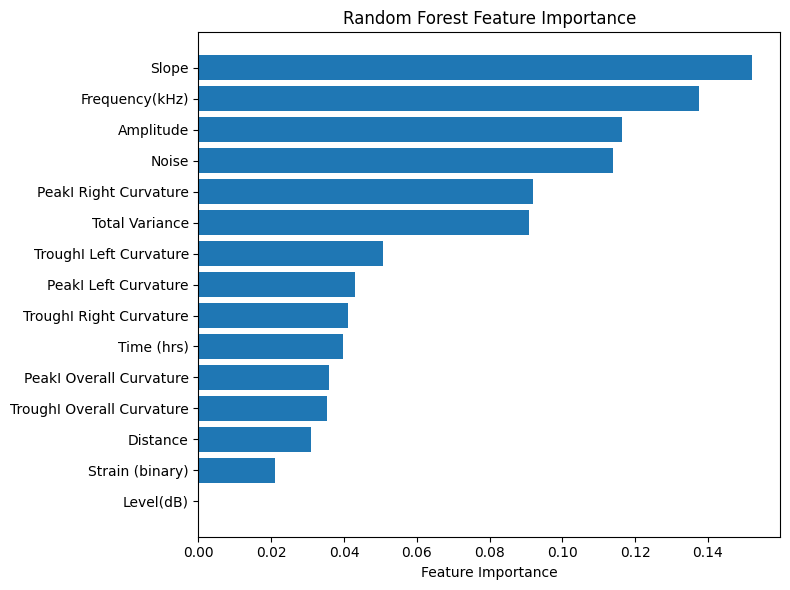

In [20]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
6              Frequency(kHz)         0.287277        0.067297
4                       Noise         0.211510        0.073307
10      PeakI Right Curvature         0.034507        0.021987
5             Strain (binary)         0.034056        0.009646
11     TroughI Left Curvature         0.017113        0.009382
9     PeakI Overall Curvature         0.007427        0.006693
13    TroughI Right Curvature         0.004616        0.003198
14                 Time (hrs)         0.003882        0.016167
8        PeakI Left Curvature         0.001494        0.007390
7              Total Variance         0.000806        0.015910
2                    Distance         0.000145        0.003055
3                   Level(dB)         0.000000        0.000000
12  TroughI Overall Curvature        -0.002005        0.003528
1                       Slope        -0.002433        0.030468
0                   A

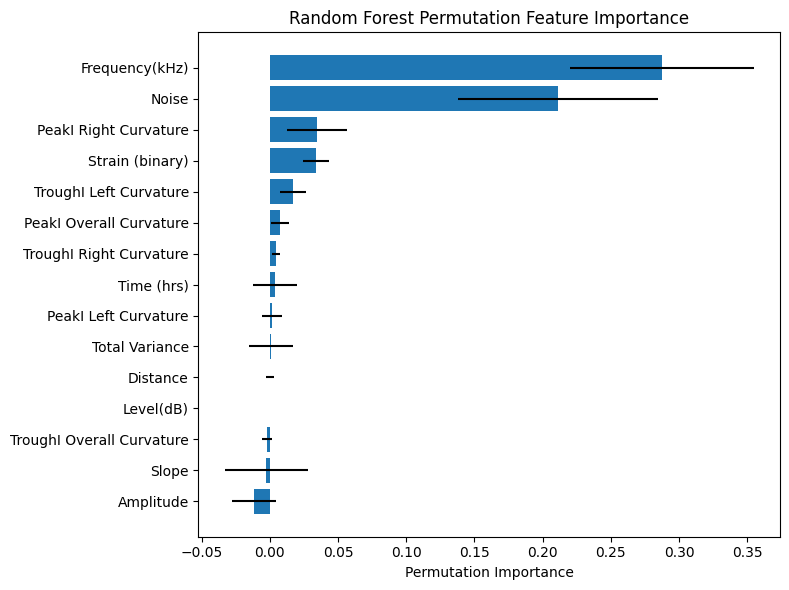

In [21]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'TroughI Overall Curvature'), Text(0, 2, 'Distance'), Text(0, 3, 'PeakI Overall Curvature'), Text(0, 4, 'TroughI Right Curvature'), Text(0, 5, 'PeakI Left Curvature'), Text(0, 6, 'TroughI Left Curvature'), Text(0, 7, 'Time (hrs)'), Text(0, 8, 'Strain (binary)'), Text(0, 9, 'Total Variance'), Text(0, 10, 'PeakI Right Curvature'), Text(0, 11, 'Amplitude'), Text(0, 12, 'Slope'), Text(0, 13, 'Frequency(kHz)'), Text(0, 14, 'Noise')]


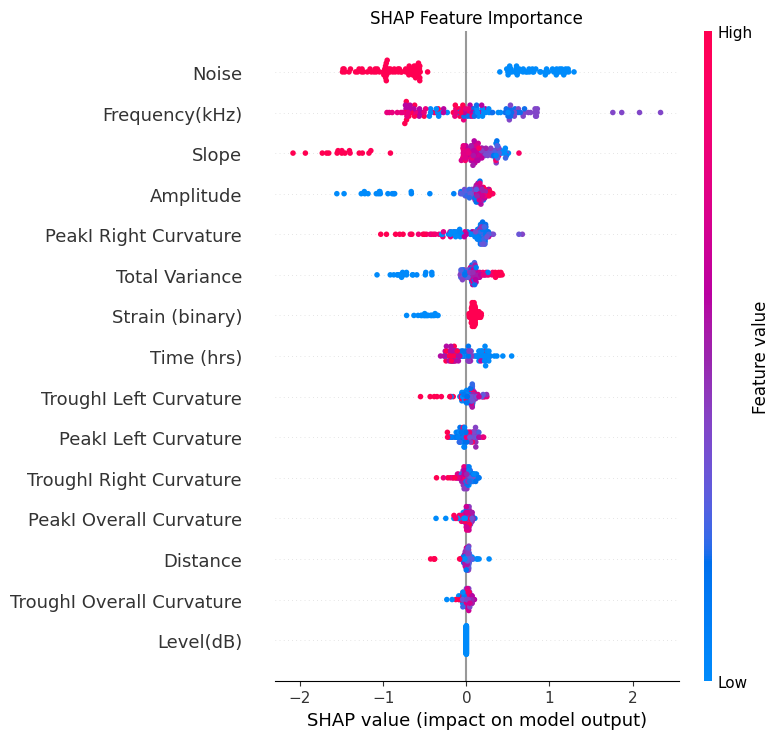

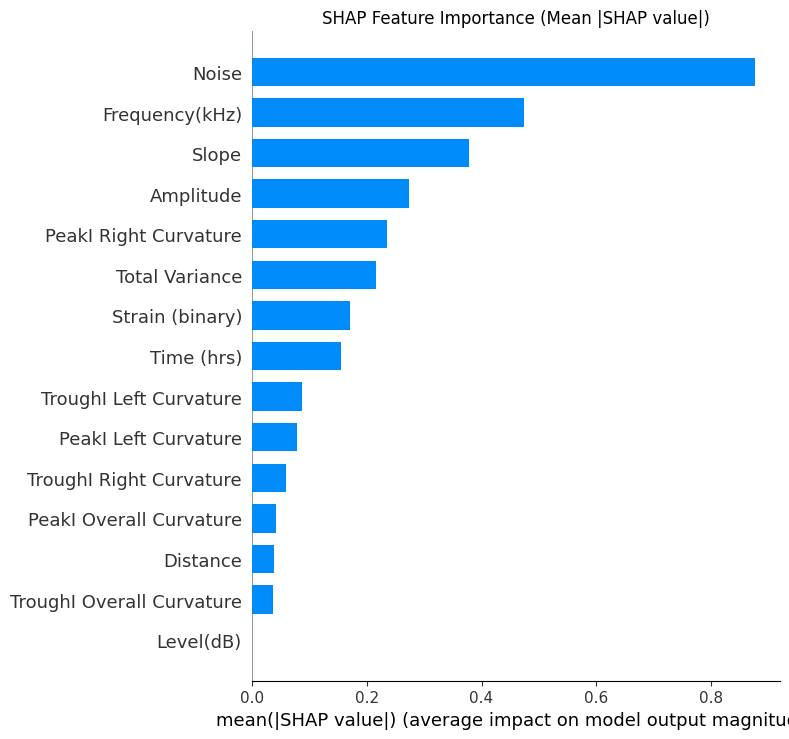

In [22]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [23]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [24]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

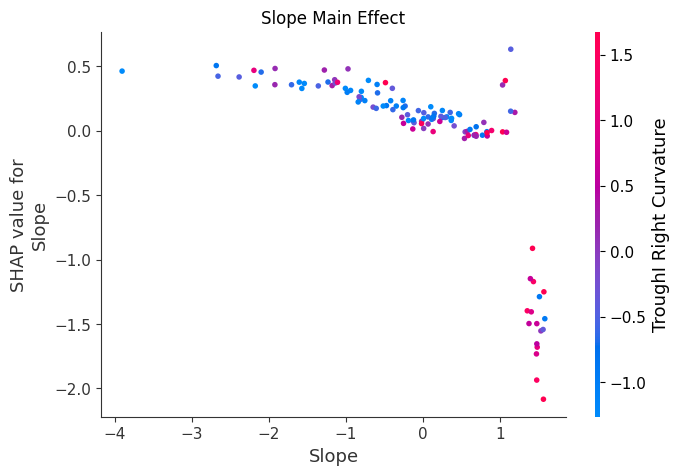

<Figure size 300x300 with 0 Axes>

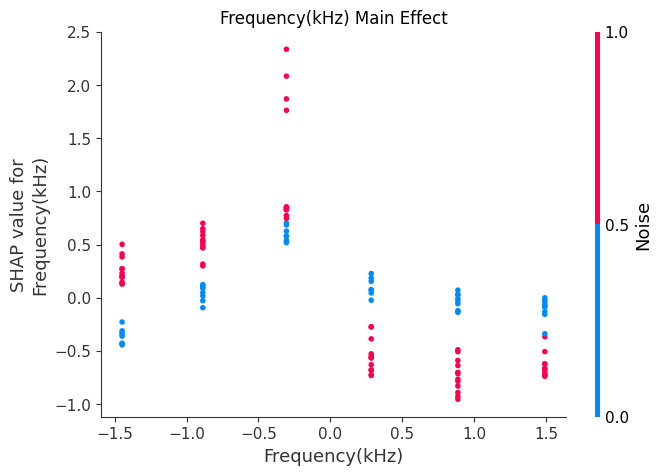

<Figure size 300x300 with 0 Axes>

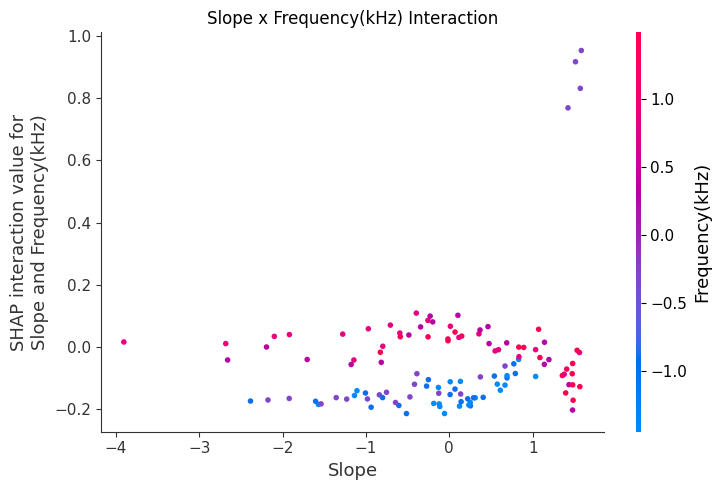

In [25]:
plot_shap_dependence(0, 1)

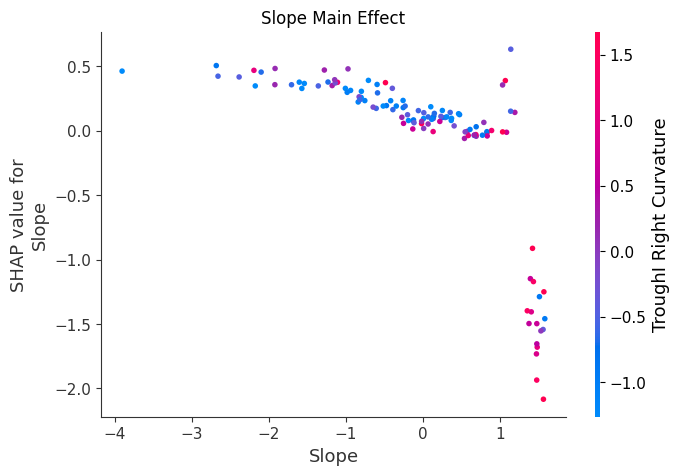

<Figure size 300x300 with 0 Axes>

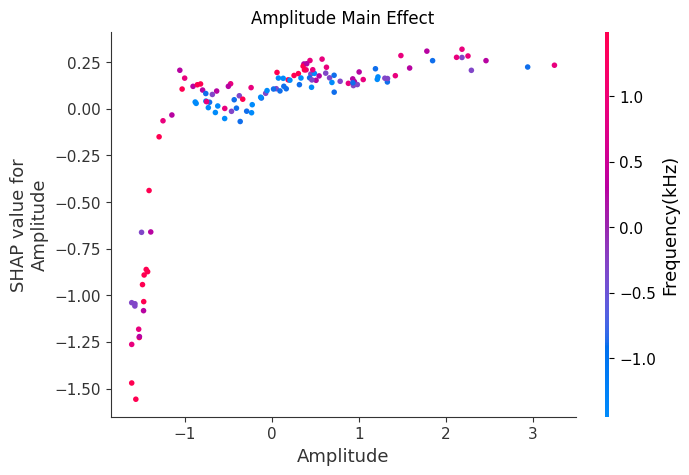

<Figure size 300x300 with 0 Axes>

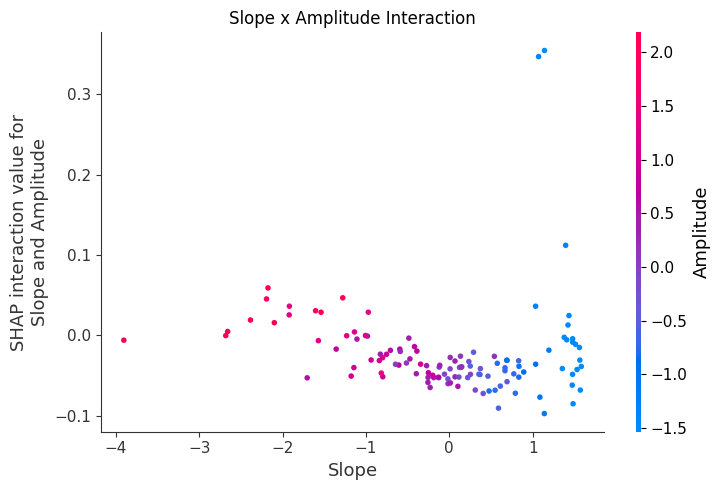

In [26]:
plot_shap_dependence(0, 2)

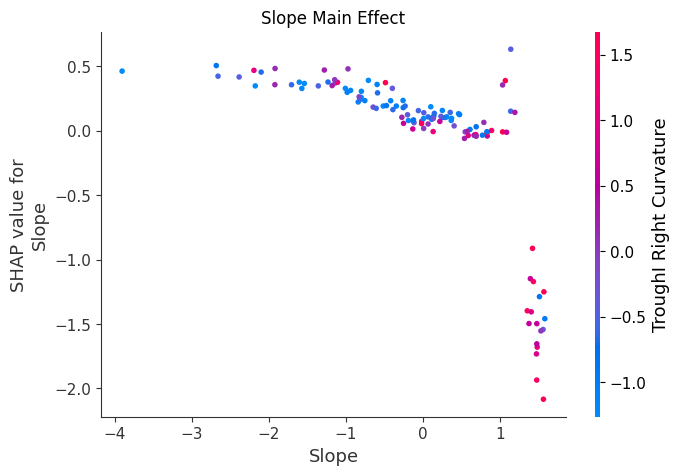

<Figure size 300x300 with 0 Axes>

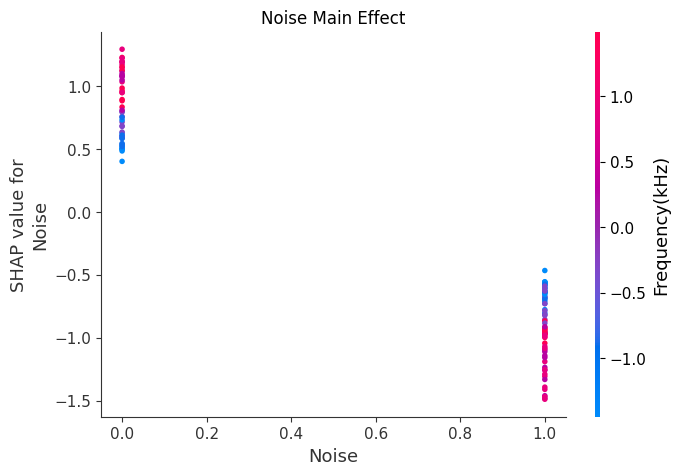

<Figure size 300x300 with 0 Axes>

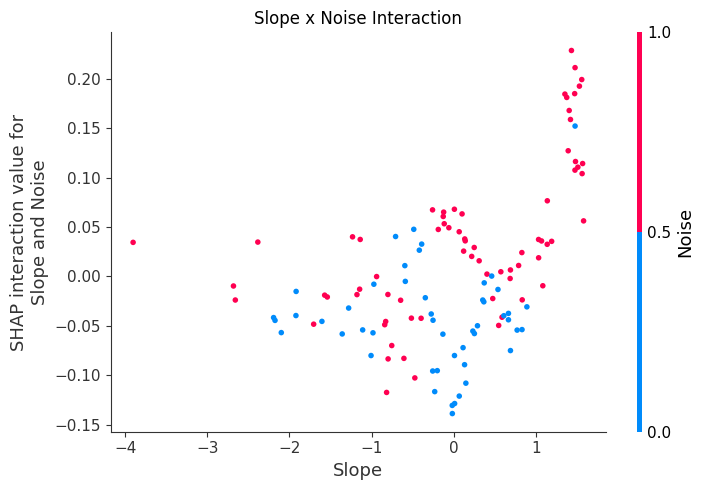

In [27]:
plot_shap_dependence(0, 3)

In [28]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [29]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 542 samples, R2: 0.077, RMSE: 1.892
20-25 dB, 870 samples, R2: 0.432, RMSE: 1.696
30-35 dB, 907 samples, R2: 0.388, RMSE: 1.857
40-45 dB, 802 samples, R2: 0.356, RMSE: 2.033
50-55 dB, 721 samples, R2: 0.412, RMSE: 2.224
60-65 dB, 719 samples, R2: 0.374, RMSE: 2.440
70-75 dB, 724 samples, R2: 0.508, RMSE: 2.597
80-85 dB, 616 samples, R2: 0.504, RMSE: 2.320
All data, 5901 samples, R2: 0.493, RMSE: 2.029


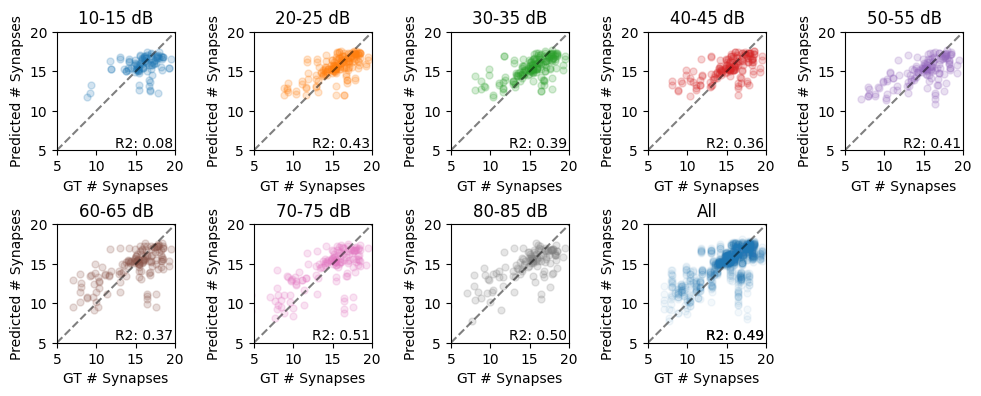

In [30]:
train_plot_result(final_clean_strained, best_rf_model)

Best RF score: 0.691, R2 on test set: 0.438
10-15 dB, 542 samples, R2: 0.026, RMSE: 1.944
20-25 dB, 870 samples, R2: 0.405, RMSE: 1.736
30-35 dB, 907 samples, R2: 0.379, RMSE: 1.871
40-45 dB, 802 samples, R2: 0.349, RMSE: 2.044
50-55 dB, 721 samples, R2: 0.434, RMSE: 2.183
60-65 dB, 719 samples, R2: 0.384, RMSE: 2.420
70-75 dB, 724 samples, R2: 0.505, RMSE: 2.605
80-85 dB, 616 samples, R2: 0.503, RMSE: 2.322
All data, 5901 samples, R2: 0.493, RMSE: 2.030


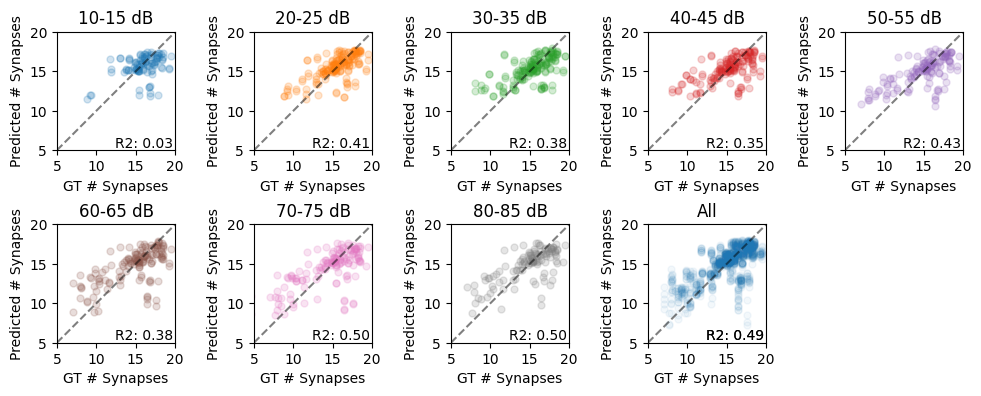

In [31]:
# Deeper trees
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

In [32]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.api as sm

features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
df_each = 4
degree_each = 3
y = smf_df["SynapsesPerIHC"].values
bs = BSplines(
    smf_df[features], df=[df_each] * len(features), degree=[degree_each] * len(features)
)
gam = GLMGam(y, smoother=bs).fit()
gam.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  616
Model:                         GLMGam   Df Residuals:                      579
Model Family:                Gaussian   Df Model:                        36.00
Link Function:               Identity   Scale:                          6.3430
Method:                         PIRLS   Log-Likelihood:                -1424.0
Date:                Sun, 22 Feb 2026   Deviance:                       3672.6
Time:                        19:09:39   Pearson chi2:                 3.67e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.5538
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Frequency_s0                   5.9193      0.870      6.807      0.000       4.215       7.624
Frequency_s1                  -5.5250      0.760     -7.266      0.000      -7.015      -4.035
Frequency_s2                   0.9692      0.380      2.548      0.011       0.224       1.715
Amplitude_s0                  16.0502      2.665      6.024      0.000      10.828      21.273
Amplitude_s1                   0.9061      6.951      0.130      0.896     -12.718      14.530
Amplitude_s2                  11.7652      8.958      1.313      0.189      -5.792      29.322
Slope_s0                      18.2472      2.401      7.601      0.000      13.542      22.952
Slope_s1                       2.3812      2.349      1.014      0.311      -2.222       6.985
Slope_s2                      12.1693      1.048     11.608      0.000      10.115      14.224
TotalVariance_s0              -7.3559      4.001     -1.838      0.066     -15.198       0.487
TotalVariance_s1               7.9547      4.096      1.942      0.052      -0.074      15.984
TotalVariance_s2              -2.5678      8.801     -0.292      0.770     -19.817      14.681
Distance_s0                    7.8482      2.581      3.041      0.002       2.790      12.907
Distance_s1                  -18.8332      2.877     -6.547      0.000     -24.471     -13.195
Distance_s2                    6.4298      1.979      3.249      0.001       2.551      10.309
Noise_s0                   -9.096e-15   5.01e-15     -1.817      0.069   -1.89e-14    7.18e-16
Noise_s1                   -3.813e-15   7.68e-15     -0.497      0.619   -1.89e-14    1.12e-14
Noise_s2                      -2.3582      0.241     -9.802      0.000      -2.830      -1.887
Time_hrs_s0                   -2.5265      1.098     -2.302      0.021      -4.678      -0.375
Time_hrs_s1                    0.7639      0.924      0.827      0.408      -1.046       2.574
Time_hrs_s2                   -1.0779      0.394     -2.736      0.006      -1.850      -0.306
PeakILeftCurvature_s0          2.5388      1.349      1.882      0.060      -0.105       5.183
PeakILeftCurvature_s1         -2.2420      2.287     -0.980      0.327      -6.725       2.241
PeakILeftCurvature_s2          1.7790      2.541      0.700      0.484      -3.200       6.758
PeakIOverallCurvature_s0      -0.5252      1.263     -0.416      0.678      -3.001       1.950
PeakIOverallCurvature_s1       1.0479      1.601      0.655      0.513      -2.089       4.185
PeakIOverallCurvature_s2      -2.0266      2.060     -0.984      0.325      -6.064       2.011
PeakIRightCurvature_s0        -0.8442      1.500     -0.563      0.574      -3.783       2.095
PeakIRightCurvature_s1        -4.9375      2.329     -2.120      0.034      -9.502      -0.373
PeakIRightCurvature_s2        -4.6642      

In [33]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.587, RMSE: 0.879
11.3Hz, 1009 samples, R2: 0.295, RMSE: 0.922
16.0Hz, 979 samples, R2: 0.063, RMSE: 1.419
22.6Hz, 953 samples, R2: 0.493, RMSE: 2.378
32.0Hz, 947 samples, R2: 0.637, RMSE: 2.244
45.2Hz, 970 samples, R2: 0.338, RMSE: 2.943
All data, 5901 samples, R2: 0.493, RMSE: 2.029


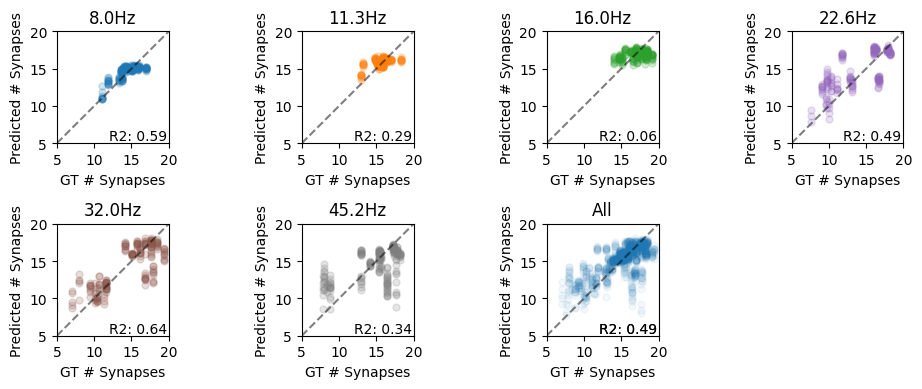

In [34]:
train_plot_result_frequency(final_clean_strained, best_rf_model)

In [35]:
from sklearn.metrics import r2_score


def train_plot_result_frequency_grouped(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            test = data[data.DataGroup == "Test"].copy()
            test["preds"] = rf_pipeline.predict(X_test1)
            grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                {"SynapsesPerIHC": "mean", "preds": "mean"}
            )
            r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
            rmse = np.sqrt(
                np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
            )
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                grouped_preds["SynapsesPerIHC"],
                grouped_preds["preds"],
                title=f"{frq}Hz",
                color=color_palette(i),
                alpha=0.5,
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    test = df[df.DataGroup == "Test"].copy()
    test["preds"] = rf_pipeline.predict(X_test)
    grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
        {"SynapsesPerIHC": "mean", "preds": "mean"}
    )
    r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
    rmse = np.sqrt(
        np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
    )
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        grouped_preds["SynapsesPerIHC"],
        grouped_preds["preds"],
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.630, RMSE: 0.807
11.3Hz, 1009 samples, R2: 0.308, RMSE: 0.942
16.0Hz, 979 samples, R2: 0.128, RMSE: 1.369
22.6Hz, 953 samples, R2: 0.582, RMSE: 2.243
32.0Hz, 947 samples, R2: 0.687, RMSE: 2.315
45.2Hz, 970 samples, R2: 0.520, RMSE: 3.060
All data, 5901 samples, R2: 0.610, RMSE: 2.058


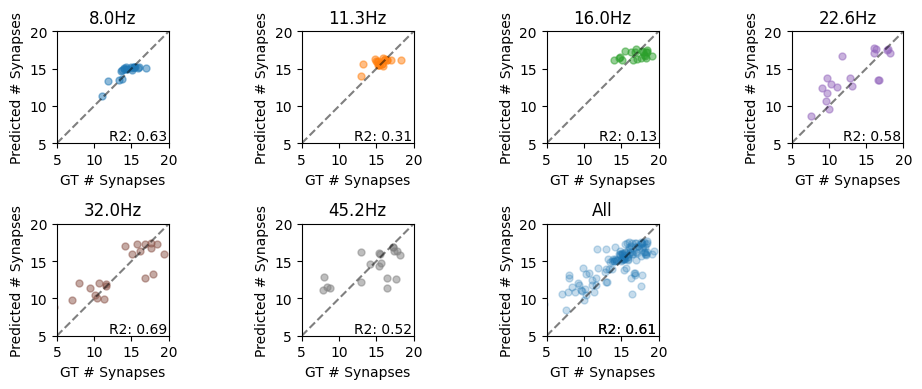

In [36]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

# XGBoost

In [37]:
from sklearn.model_selection import GridSearchCV
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 50, 100, 150, 200, 300],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best XGB params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best XGB score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
xgb_model = clf_search.best_estimator_

Best XGB params: {'clf__max_depth': 4, 'clf__n_estimators': 25}
Best XGB score: 0.439, R2 on test set: 0.451


8.0Hz, 1043 samples, R2: 0.510, RMSE: 0.957
11.3Hz, 1009 samples, R2: 0.139, RMSE: 1.019
16.0Hz, 979 samples, R2: -0.009, RMSE: 1.473
22.6Hz, 953 samples, R2: 0.370, RMSE: 2.652
32.0Hz, 947 samples, R2: 0.603, RMSE: 2.346
45.2Hz, 970 samples, R2: 0.267, RMSE: 3.097
All data, 5901 samples, R2: 0.506, RMSE: 2.004


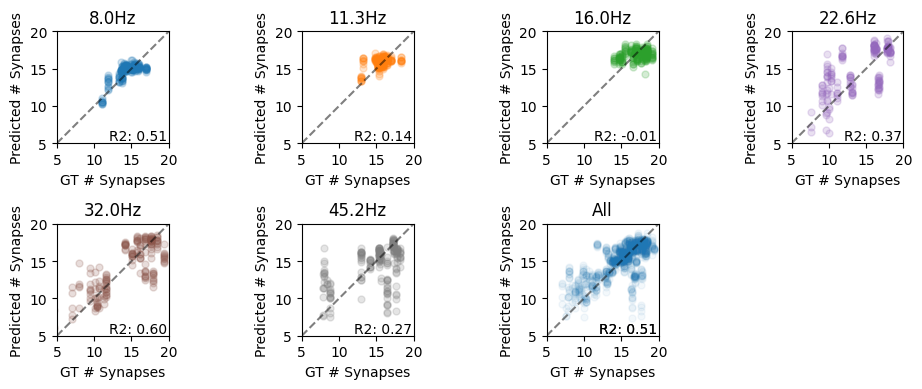

In [38]:
train_plot_result_frequency(final_clean_strained, xgb_model)

8.0Hz, 1043 samples, R2: 0.576, RMSE: 0.865
11.3Hz, 1009 samples, R2: 0.206, RMSE: 1.009
16.0Hz, 979 samples, R2: 0.076, RMSE: 1.409
22.6Hz, 953 samples, R2: 0.525, RMSE: 2.392
32.0Hz, 947 samples, R2: 0.726, RMSE: 2.163
45.2Hz, 970 samples, R2: 0.538, RMSE: 2.999
All data, 5901 samples, R2: 0.642, RMSE: 1.971


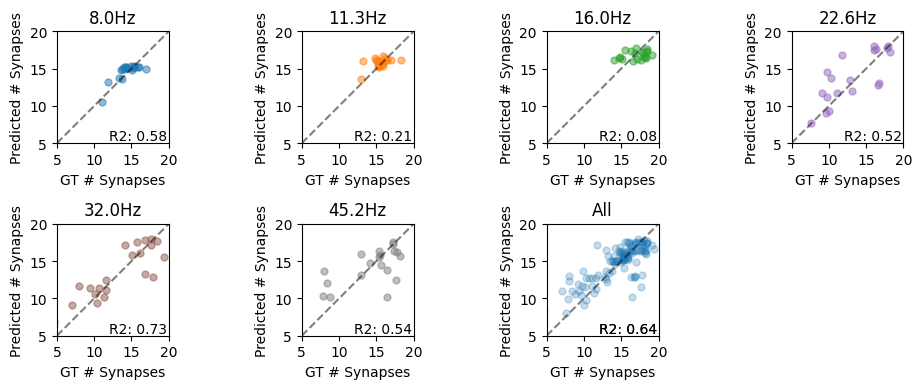

In [39]:
train_plot_result_frequency_grouped(final_clean_strained, xgb_model)